In [1]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import sklearn as sk

import statsmodels.api as sm 

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Level 1 
# Task 1: Data Cleaning and Preprocessing

In [2]:
# Loading the dataset 
column_names = [ 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
    
]

b_housing = pd.read_csv(
    r"c:\Users\DELL\Downloads\4) house Prediction Data Set.csv",
    sep=r'\s+',
    engine= 'python',
    header= None,
    names = column_names,
    na_values= ['NA', 'missing', '', '?']
)

b_housing_copied = b_housing
print(b_housing_copied.shape )

b_housing_copied.head(3)


(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


In [3]:
# Checking data Quality 

print ("Missing values per column:\n",b_housing_copied.isna().sum())

Missing values per column:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [4]:
print ("\nDuplicate rows:", b_housing_copied.duplicated().sum())

print ("\nData types:\n", b_housing_copied.dtypes)

print ("\nData info:\n", b_housing_copied.info())


Duplicate rows: 0

Data types:
 CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV   

In [5]:
# Outlier detection & handling

def cap_outliers_iqr(series, multiplier = 1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return series.clip(lower = lower, upper = upper)

outlier_cols = ['CRIM', 'ZN', 'RM', 'DIS', 'B', 'LSTAT', 'MEDV' ]

for col in outlier_cols: 
    b_housing_copied[col] = cap_outliers_iqr(b_housing_copied[col])
    
    print( b_housing_copied[outlier_cols].describe().round(2))

         CRIM      ZN      RM     DIS       B   LSTAT    MEDV
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00
mean     2.23   11.36    6.28    3.80  356.67   12.65   22.53
std      3.31   23.32    0.70    2.11   91.29    7.14    9.20
min      0.01    0.00    3.56    1.13    0.32    1.73    5.00
25%      0.08    0.00    5.89    2.10  375.38    6.95   17.02
50%      0.26    0.00    6.21    3.21  391.44   11.36   21.20
75%      3.68   12.50    6.62    5.19  396.22   16.96   25.00
max      9.07  100.00    8.78   12.13  396.90   37.97   50.00
         CRIM      ZN      RM     DIS       B   LSTAT    MEDV
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00
mean     2.23    6.96    6.28    3.80  356.67   12.65   22.53
std      3.31   12.03    0.70    2.11   91.29    7.14    9.20
min      0.01    0.00    3.56    1.13    0.32    1.73    5.00
25%      0.08    0.00    5.89    2.10  375.38    6.95   17.02
50%      0.26    0.00    6.21    3.21  391.44   11.36   21.20
75%     

In [6]:
#   Standardizing formats & fixing data types

b_housing_copied['CHAS'] =b_housing_copied['CHAS'].astype('category')

b_housing_copied['RAD'] =b_housing_copied['RAD'].astype('category')

# Ensuring numeric columns are float

numeric_cols = ['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','TAX','PTRATIO','B','LSTAT','MEDV']

b_housing_copied[numeric_cols] = b_housing_copied[numeric_cols].astype(float)

b_housing_copied.dtypes

CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD        category
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
MEDV        float64
dtype: object

In [7]:
b_housing_copied['RM2']          = b_housing_copied['RM'] ** 2                    
b_housing_copied['LSTAT_bin']    = pd.qcut(b_housing_copied['LSTAT'], q=5, labels=False)  
b_housing_copied['CRIM_log']     = np.log1p(b_housing_copied['CRIM'])              
b_housing_copied['PRICE_per_ROOM'] = b_housing_copied['MEDV'] / b_housing_copied['RM']

In [8]:

print("FINAL CLEANED DATASET SUMMARY")
print("="*40)
print("Shape:", b_housing_copied.shape)
print("\nMissing values total:", b_housing_copied.isna().sum().sum())
print("\nSample of cleaned data:")
print(b_housing_copied.head(5).round(2))


FINAL CLEANED DATASET SUMMARY
Shape: (506, 18)

Missing values total: 0

Sample of cleaned data:
   CRIM    ZN  INDUS CHAS   NOX    RM   AGE   DIS RAD    TAX  PTRATIO       B  \
0  0.01  18.0   2.31    0  0.54  6.58  65.2  4.09   1  296.0     15.3  396.90   
1  0.03   0.0   7.07    0  0.47  6.42  78.9  4.97   2  242.0     17.8  396.90   
2  0.03   0.0   7.07    0  0.47  7.18  61.1  4.97   2  242.0     17.8  392.83   
3  0.03   0.0   2.18    0  0.46  7.00  45.8  6.06   3  222.0     18.7  394.63   
4  0.07   0.0   2.18    0  0.46  7.15  54.2  6.06   3  222.0     18.7  396.90   

   LSTAT  MEDV    RM2  LSTAT_bin  CRIM_log  PRICE_per_ROOM  
0   4.98  24.0  43.23          0      0.01            3.65  
1   9.14  21.6  41.23          1      0.03            3.36  
2   4.03  34.7  51.62          0      0.03            4.83  
3   2.94  33.4  48.97          0      0.03            4.77  
4   5.33  36.2  51.08          0      0.07            5.07  


In [9]:
# Exporting the cleaned dataset

# b_housing_copied.to_csv('housing_prediction_cleaned.csv', index=False)

# Task 2: Exploratory Data Analysis (EDA)

In [10]:
#  Summary Statistics

print("\nDescriptive statistics of main variables:")
print(b_housing_copied[['CRIM','RM','LSTAT','MEDV','PRICE_per_ROOM']].describe().round(2))


Descriptive statistics of main variables:
         CRIM      RM   LSTAT    MEDV  PRICE_per_ROOM
count  506.00  506.00  506.00  506.00          506.00
mean     2.23    6.28   12.61   21.88            3.44
std      3.31    0.63    7.02    7.60            0.98
min      0.01    4.78    1.73    5.06            0.89
25%      0.08    5.89    6.95   17.02            2.86
50%      0.26    6.21   11.36   21.20            3.47
75%      3.68    6.62   16.96   25.00            4.04
max      9.07    7.73   31.96   36.96            7.44


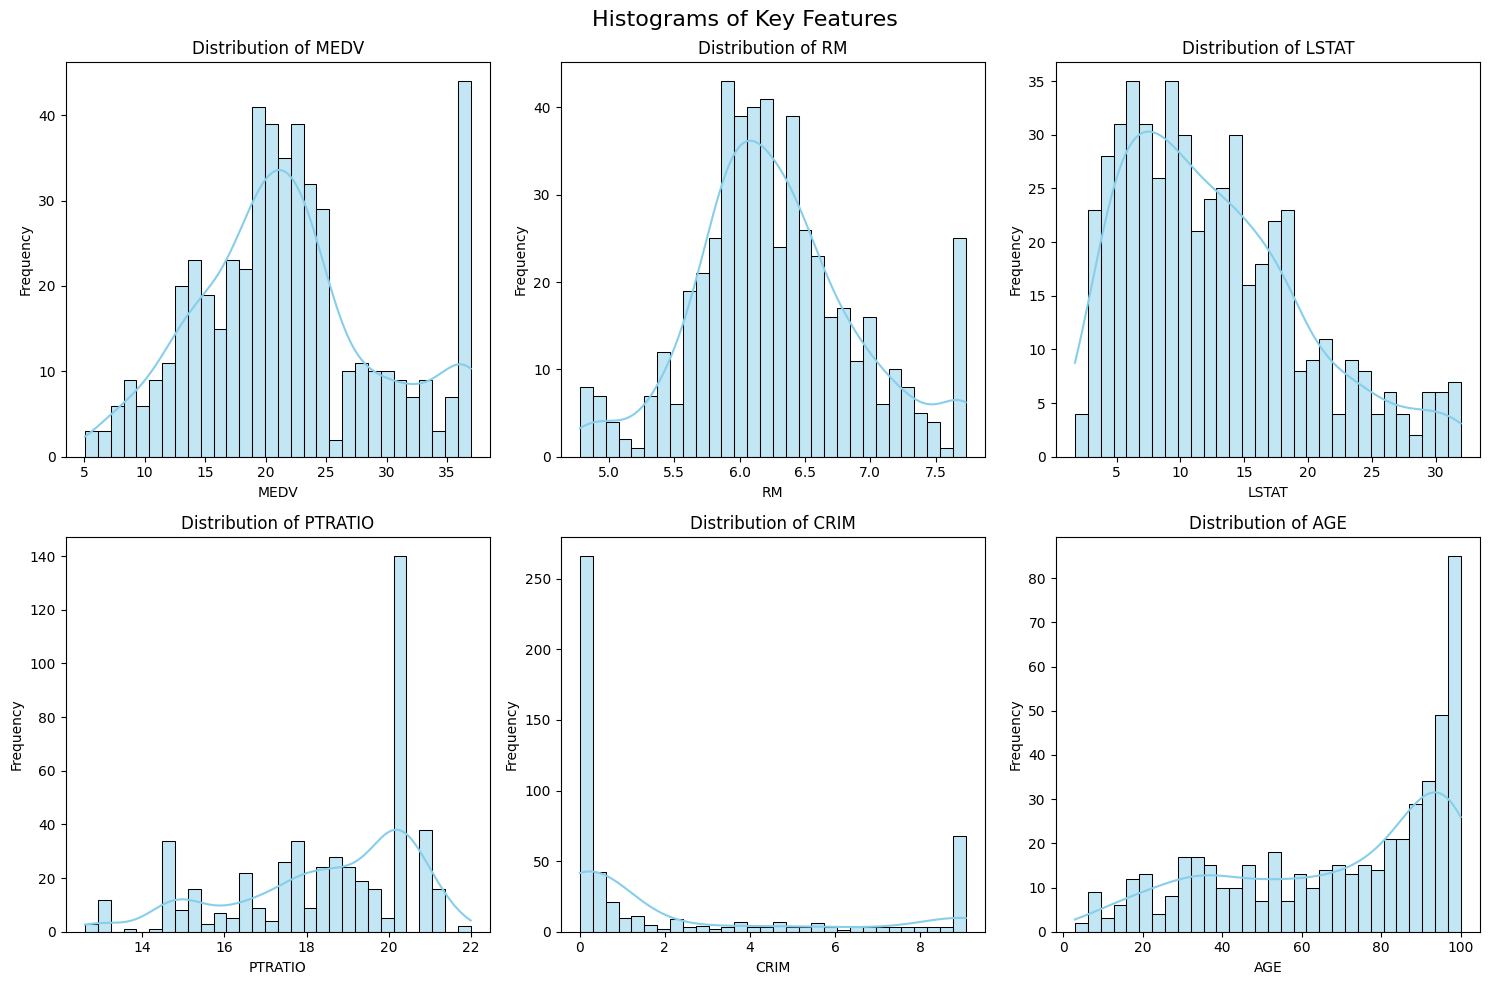

In [11]:
#  Histograms - Distribution of Features 
plt.figure(figsize=(15, 10))

features = ['MEDV', 'RM', 'LSTAT', 'PTRATIO', 'CRIM', 'AGE']
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(b_housing_copied[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.suptitle('Histograms of Key Features', fontsize=16)
plt.tight_layout()
plt.savefig('boston_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

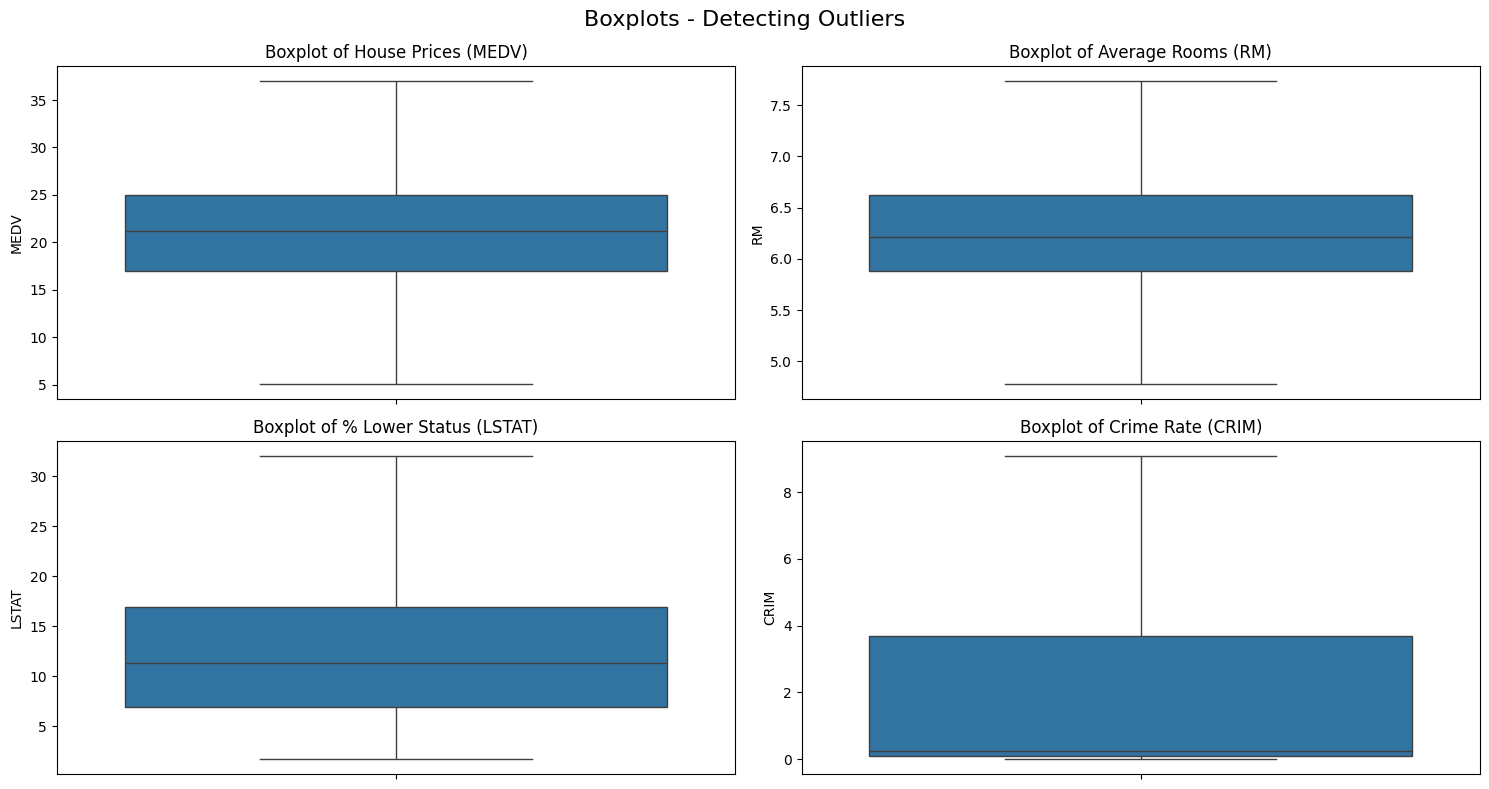

In [12]:
#   Boxplots - Outlier Detection 
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
sns.boxplot(y=b_housing_copied['MEDV'])
plt.title('Boxplot of House Prices (MEDV)')

plt.subplot(2, 2, 2)
sns.boxplot(y=b_housing_copied['RM'])
plt.title('Boxplot of Average Rooms (RM)')

plt.subplot(2, 2, 3)
sns.boxplot(y=b_housing_copied['LSTAT'])
plt.title('Boxplot of % Lower Status (LSTAT)')

plt.subplot(2, 2, 4)
sns.boxplot(y=b_housing_copied['CRIM'])
plt.title('Boxplot of Crime Rate (CRIM)')

plt.suptitle('Boxplots - Detecting Outliers', fontsize=16)
plt.tight_layout()
plt.savefig('boston_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

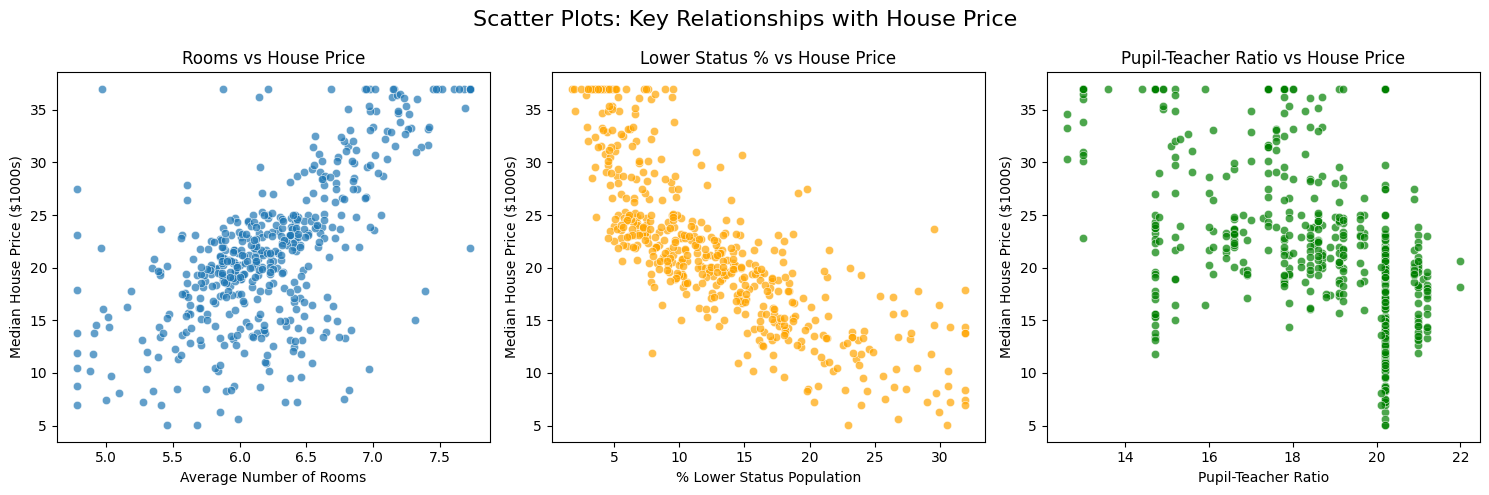

In [13]:
#  Scatter Plots - Relationships 
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='RM', y='MEDV', data=b_housing_copied, alpha=0.7)
plt.title('Rooms vs House Price')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Price ($1000s)')

plt.subplot(1, 3, 2)
sns.scatterplot(x='LSTAT', y='MEDV', data=b_housing_copied, alpha=0.7, color='orange')
plt.title('Lower Status % vs House Price')
plt.xlabel('% Lower Status Population')
plt.ylabel('Median House Price ($1000s)')

plt.subplot(1, 3, 3)
sns.scatterplot(x='PTRATIO', y='MEDV', data=b_housing_copied, alpha=0.7, color='green')
plt.title('Pupil-Teacher Ratio vs House Price')
plt.xlabel('Pupil-Teacher Ratio')
plt.ylabel('Median House Price ($1000s)')

plt.suptitle('Scatter Plots: Key Relationships with House Price', fontsize=16)
plt.tight_layout()
plt.savefig('boston_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

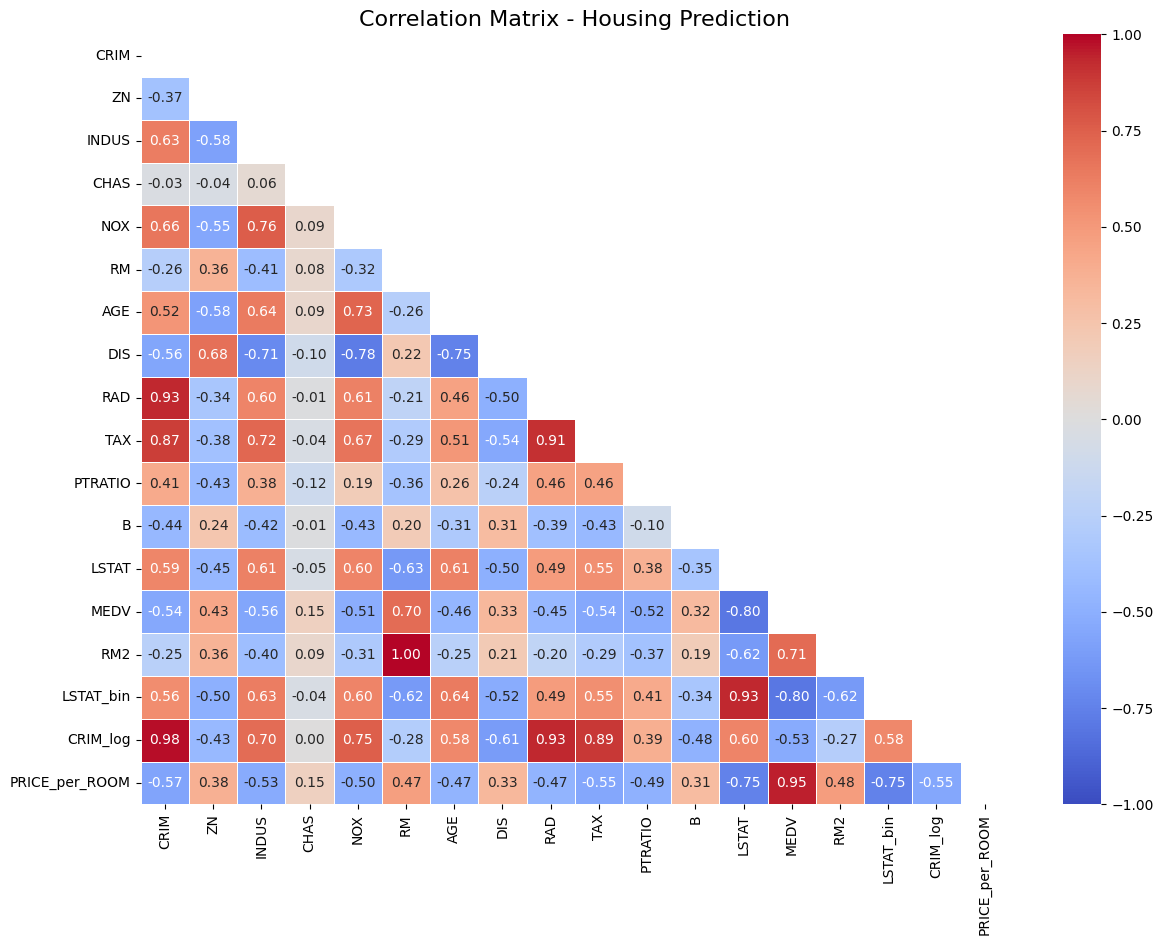

In [14]:
#  Correlation Heatmap

plt.figure(figsize=(14, 10))
corr = b_housing_copied.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Correlation Matrix - Housing Prediction', fontsize=16)
plt.savefig('boston_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
#  Strongest relationships with target (MEDV)

print("\nTop correlations with MEDV:")
print(
    corr['MEDV']
    .drop('MEDV')
    .sort_values(ascending=False)
    .round(3)
)


Top correlations with MEDV:
PRICE_per_ROOM    0.95
RM2               0.71
RM                0.70
ZN                0.43
DIS               0.33
B                 0.32
CHAS              0.15
RAD              -0.45
AGE              -0.46
NOX              -0.51
PTRATIO          -0.52
CRIM_log         -0.53
CRIM             -0.54
TAX              -0.54
INDUS            -0.56
LSTAT            -0.80
LSTAT_bin        -0.80
Name: MEDV, dtype: float64


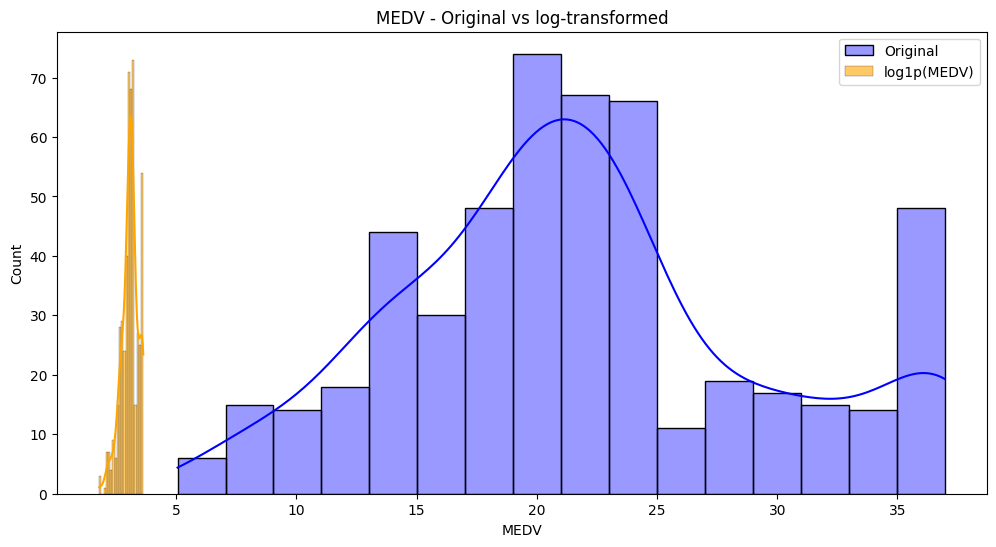

In [16]:
#  Log transform skewed features 

b_housing_copied_log = b_housing_copied.copy()
for col in ['CRIM', 'ZN', 'DIS', 'B', 'MEDV']:
    if (b_housing_copied[col] > 0).all():
        b_housing_copied_log[col] = np.log1p(b_housing_copied[col])

# Comparing distributions before/after
plt.figure(figsize=(12, 6))
sns.histplot(b_housing_copied['MEDV'], kde=True, color='blue', alpha=0.4, label='Original')
sns.histplot(b_housing_copied_log['MEDV'], kde=True, color='orange', alpha=0.6, label='log1p(MEDV)')
plt.title('MEDV - Original vs log-transformed')
plt.legend()
plt.show()

# Task 3: Basic Data Visualization

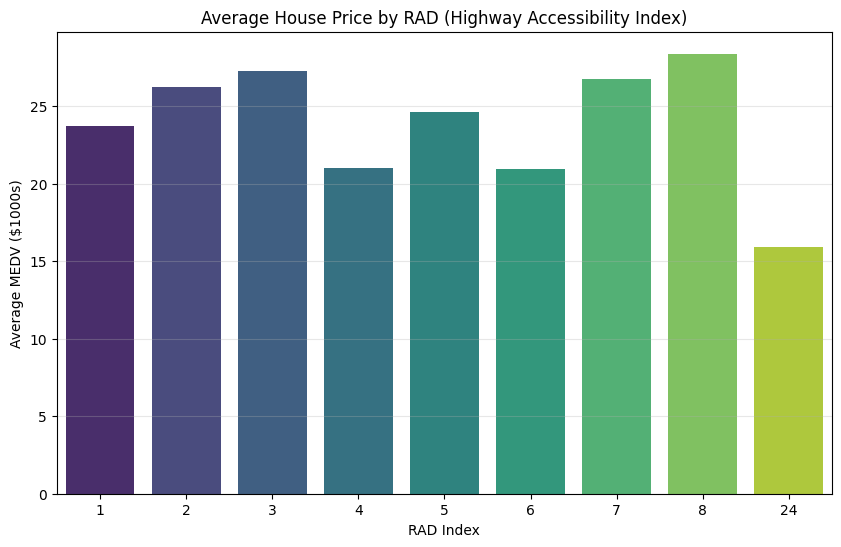

In [17]:
#  Bar Plot - Average Price by RAD 

plt.figure(figsize=(10, 6))
rad_avg_price = b_housing_copied.groupby('RAD', observed=False)['MEDV'].mean().sort_values(ascending=False)
sns.barplot(x=rad_avg_price.index, 
            y=rad_avg_price.values, 
            hue=rad_avg_price.index, 
            palette='viridis', 
            legend=False
)
plt.title('Average House Price by RAD (Highway Accessibility Index)')
plt.xlabel('RAD Index')
plt.ylabel('Average MEDV ($1000s)')
plt.grid(axis='y', alpha=0.3)
plt.savefig('boston_barplot_rad.png', dpi=300, bbox_inches='tight')
plt.show()

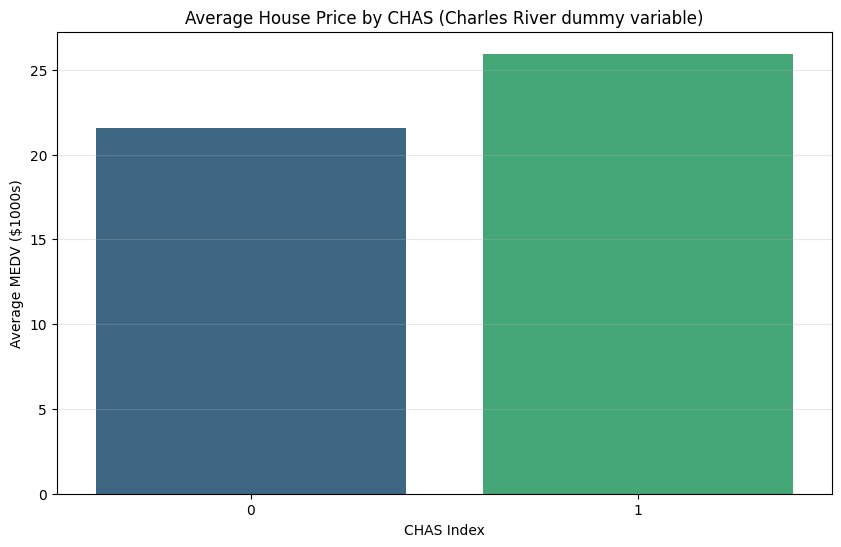

In [18]:
#  Bar Plot - Average Price by CHAS 

plt.figure(figsize=(10, 6))
chas_avg_price = b_housing_copied.groupby('CHAS', observed=False)['MEDV'].mean().sort_values(ascending=False)
sns.barplot(x=chas_avg_price.index, 
            y=chas_avg_price.values, 
            hue=chas_avg_price.index, 
            palette='viridis', 
            legend=False
)
plt.title('Average House Price by CHAS (Charles River dummy variable)')
plt.xlabel('CHAS Index')
plt.ylabel('Average MEDV ($1000s)')
plt.grid(axis='y', alpha=0.3)
plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()

# Level 2 
# Task 1: Regression Analysis

In [19]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from io import StringIO

In [20]:
# importng ad cleaning the dataet

house_original = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Python_Projects\housing_prediction_cleaned.csv" )


house_copied = house_original
house_copied.columns 

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV', 'RM2', 'LSTAT_bin', 'CRIM_log',
       'PRICE_per_ROOM'],
      dtype='object')

In [21]:
print("Info: \n", house_copied.info())

print(house_copied.head(5))

print("Shape:  \n", house_copied.shape) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CRIM            506 non-null    float64
 1   ZN              506 non-null    float64
 2   INDUS           506 non-null    float64
 3   CHAS            506 non-null    int64  
 4   NOX             506 non-null    float64
 5   RM              506 non-null    float64
 6   AGE             506 non-null    float64
 7   DIS             506 non-null    float64
 8   RAD             506 non-null    int64  
 9   TAX             506 non-null    float64
 10  PTRATIO         506 non-null    float64
 11  B               506 non-null    float64
 12  LSTAT           506 non-null    float64
 13  MEDV            506 non-null    float64
 14  RM2             506 non-null    float64
 15  LSTAT_bin       506 non-null    int64  
 16  CRIM_log        506 non-null    float64
 17  PRICE_per_ROOM  506 non-null    flo

In [22]:
# Predicting  MEDV from LSTAT 

X_house = house_copied[['LSTAT']]  #independent

y_house = house_copied[['MEDV']]  # dependent


# Train / Test split
X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_house, y_house, test_size= 0.2, random_state= 42
    )




# Fitting linear regression model
model_house = LinearRegression()
model_house.fit(X_house_train, y_house_train)


intercept = model_house.intercept_[0]
slope = model_house.coef_[0][0]



print(f"Model equation:  LSTAT = {slope:.3f} x MEDV + {intercept:.3f} \n")



# Making predictions on test set
y_house_pred = model_house.predict(X_house_test)
y_house_pred


# Evaluating the model

print("Test set performance:")

print ("•Intercept: \n", round(model_house.intercept_[0], 3))

print ("•Coefficient: \n", round(model_house.coef_[0] [0], 3),)

print ("•R²: \n", round(r2_score(y_house_test,y_house_pred), 3))

print("•RMSE: \n", round(np.sqrt(mean_squared_error(y_house_test,y_house_pred)),3))

Model equation:  LSTAT = -0.874 x MEDV + 32.972 

Test set performance:
•Intercept: 
 32.972
•Coefficient: 
 -0.874
•R²: 
 0.665
•RMSE: 
 4.049


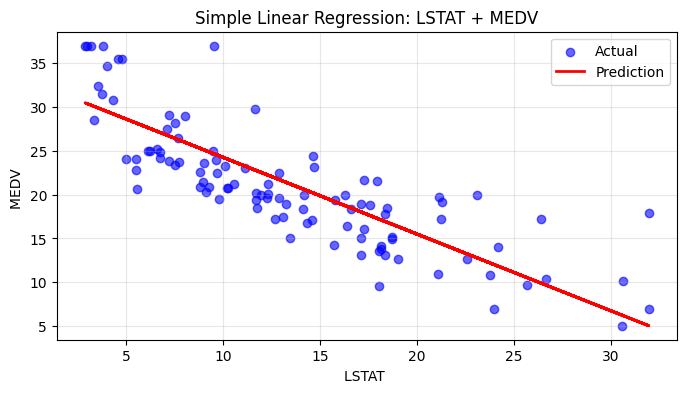

In [23]:
# Visualizing it 

plt.figure(figsize=(8,4))
plt.scatter(X_house_test, y_house_test, color='blue', label='Actual', alpha=0.6)
plt.plot(X_house_test, y_house_pred, color='red', linewidth=2, label='Prediction')
plt.xlabel('LSTAT ')
plt.ylabel('MEDV ')
plt.title('Simple Linear Regression: LSTAT + MEDV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 2: Time Series Analysis

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

In [25]:
#  Loading the dataset


stock_original = pd.read_csv(r"C:\Users\DELL\Downloads\2) Stock Prices Data Set.csv")
stock_copied = stock_original
stock_copied.head(5)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [26]:
# Converting date to datetime and sorting

stock_copied['date'] = pd.to_datetime(stock_copied['date'])
stock_copied_sort = stock_copied.sort_values('date')


print("Dataset loaded!")
print('Date range:', stock_copied['date'].min(), 'to', stock_copied['date'].max())
print("Unique stocks:",stock_copied['symbol'].nunique())

Dataset loaded!
Date range: 2014-01-02 00:00:00 to 2017-12-29 00:00:00
Unique stocks: 505


In [27]:
# Focusing on AAPL trend

aapl = stock_copied[stock_copied['symbol'] == 'AAPL'].copy()
aapl =  aapl.set_index('date')
close = aapl['close']

print(f"\nAAPL data points: {len(close)}")
print(f"Starting price (2014-01-02: ${close.iloc[0]:.2f})")
print(f"Ending price (2017-12-29: ${close.iloc[-1]:.2f})")


AAPL data points: 1007
Starting price (2014-01-02: $79.02)
Ending price (2017-12-29: $169.23)


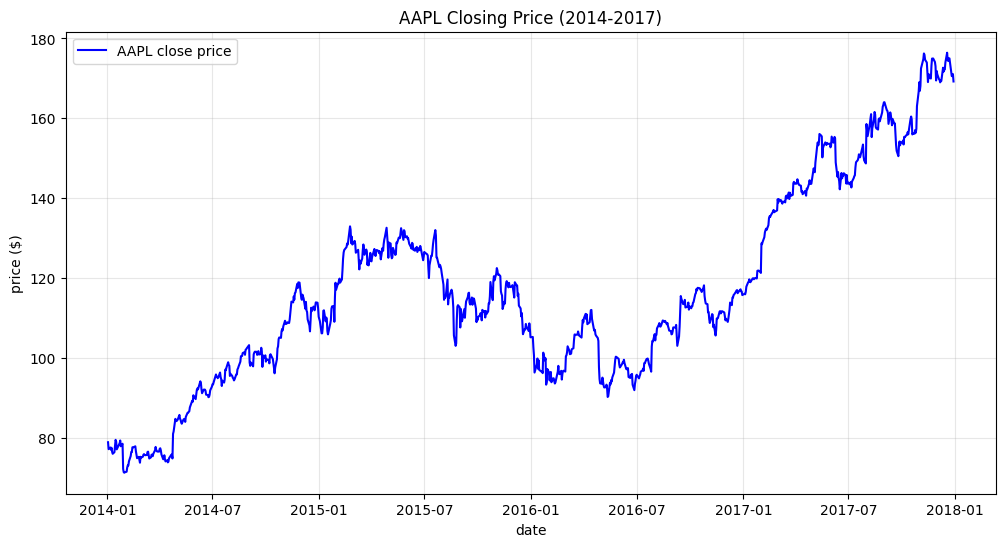

In [28]:
# Plotting the raw time series

plt.figure(figsize=(12, 6))
plt.plot(close, label='AAPL close price', color='blue')
plt.title('AAPL Closing Price (2014-2017)')
plt.xlabel('date')
plt.ylabel('price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

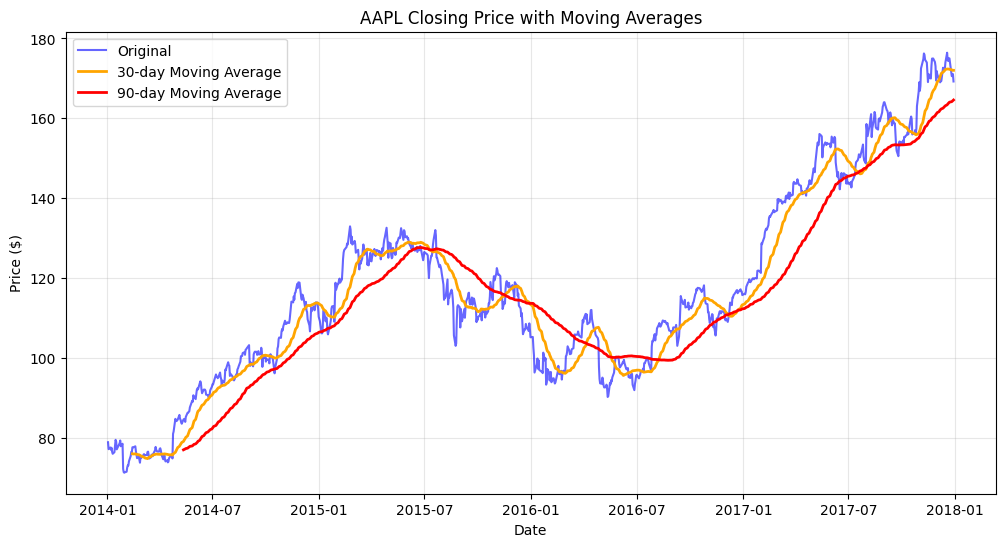

In [29]:
# Moving Average Smoothing



ma30 = close.rolling(window=30).mean()
ma90 = close.rolling(window=90).mean()


plt.figure(figsize=(12, 6))
plt.plot(close, label='Original', color='blue', alpha=0.6)
plt.plot(ma30, label='30-day Moving Average', color='orange', linewidth=2)
plt.plot(ma90, label='90-day Moving Average', color='red', linewidth=2)
plt.title('AAPL Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

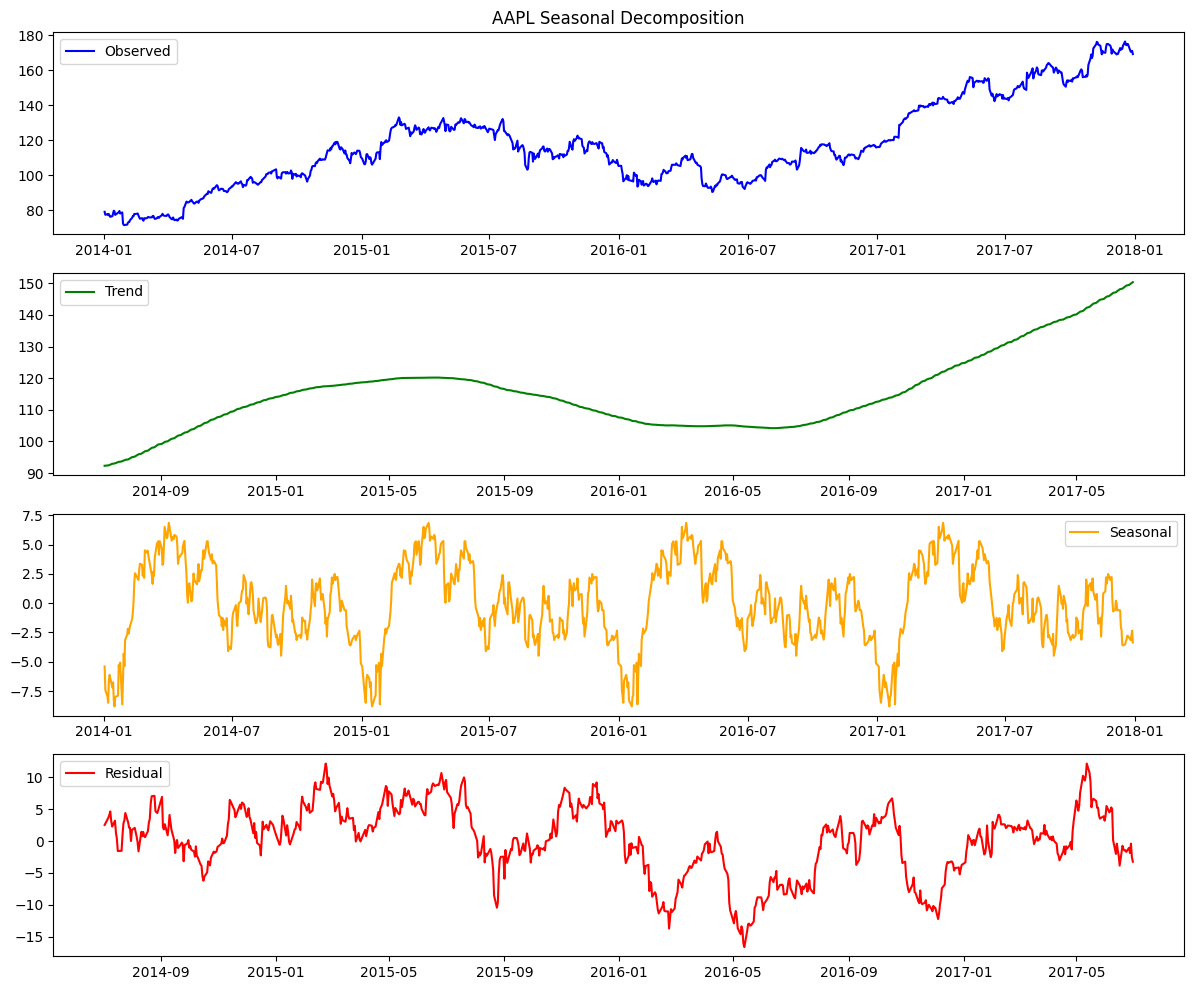

In [30]:
# Seasonal Decomposition
# period = 252 ≈ trading days in a year


decomp = seasonal_decompose(close, model='additive', period=252)

plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(decomp.observed, label='Observed', color='blue')
plt.title('AAPL Seasonal Decomposition')
plt.legend()

plt.subplot(412)
plt.plot(decomp.trend, label='Trend', color='green')
plt.legend()

plt.subplot(413)
plt.plot(decomp.seasonal, label='Seasonal', color='orange')
plt.legend()

plt.subplot(414)
plt.plot(decomp.resid, label='Residual', color='red')
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
# Summary of patterns


print("KEY FINDINGS : \n")
print("="*50)
print("• Trend: Strong upward (from ~$79 → ~$169)")
print("• Seasonality: Mild yearly cycles visible in decomposition")
print("• Residuals: Mostly random noise with occasional volatility spikes")
print("• Moving Averages: Perfectly smooth the daily fluctuations")


KEY FINDINGS : 

• Trend: Strong upward (from ~$79 → ~$169)
• Seasonality: Mild yearly cycles visible in decomposition
• Residuals: Mostly random noise with occasional volatility spikes
• Moving Averages: Perfectly smooth the daily fluctuations


#  Level 3 
# Task 1: Predictive Modeling (Classification)

In [32]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Loading  the pre-split datasets


churn_80_Original = pd.read_csv(r"C:\Users\DELL\Downloads\churn-bigml-80.csv")
churn_80_copied = churn_80_Original
churn_80_copied.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [34]:
churn_20_original = pd.read_csv(r"C:\Users\DELL\Downloads\churn-bigml-20.csv")
churn_20_copied = churn_20_original
churn_20_copied

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,WI,114,415,No,Yes,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2,False
663,AL,106,408,No,Yes,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1,False
664,VT,60,415,No,No,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3,False
665,WV,159,415,No,No,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1,False


In [35]:
print ("Train shape :", churn_80_copied.shape )
print ("Test shape:", churn_20_copied.shape )
print("Target distribution in Train: \n", churn_80_copied['Churn'].value_counts(normalize=True))

Train shape : (2666, 20)
Test shape: (667, 20)
Target distribution in Train: 
 Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


In [36]:
# Preprocessing

x_churn_80 = churn_80_copied.drop('Churn',axis = 1)
y_churn_80 = churn_80_copied['Churn'].astype(int)
x_churn_20 = churn_20_copied.drop("Churn", axis=1)
y_churn_20 = churn_20_copied['Churn'].astype(int)


# Categorical & Numerical columns

cat_cols = ['State','International plan', 'Voice mail plan' ]
num_cols = [ col for col in x_churn_80.columns if col not in cat_cols]


# Preprocessor

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)])



In [37]:
# Defininig 3 models


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

In [38]:
# Training and Evaluating each model 



results = []

for name, model in models.items(): 
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])
    
    pipe.fit(x_churn_80, y_churn_80)
    y_pred = pipe.predict(x_churn_20)
    
    acc = accuracy_score(y_churn_20, y_pred)
    prec = precision_score(y_churn_20, y_pred)
    rec = recall_score(y_churn_20, y_pred)
    f1 = f1_score(y_churn_20, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4), 
        'Precision': round (prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })
    
    print(f"\n=== {name} ===")
    print(classification_report(y_churn_20,y_pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       572
           1       0.48      0.22      0.30        95

    accuracy                           0.85       667
   macro avg       0.68      0.59      0.61       667
weighted avg       0.82      0.85      0.83       667


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       572
           1       0.69      0.76      0.72        95

    accuracy                           0.92       667
   macro avg       0.82      0.85      0.84       667
weighted avg       0.92      0.92      0.92       667


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       572
           1       0.97      0.61      0.75        95

    accuracy                           0.94       667
   macro avg       0.95      0.80      0.86       667

In [39]:
# Summary Table

results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("MODEL COMPARISON (on 20% Test set)")
print("=" * 60)
print(results_df.to_string(index=False))


MODEL COMPARISON (on 20% Test set)
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8546     0.4773  0.2211    0.3022
      Decision Tree    0.9160     0.6857  0.7579    0.7200
      Random Forest    0.9415     0.9667  0.6105    0.7484


In [40]:
# Hyperparameter Tuning – Random Forest


print("\nTuning Random Forest with GridSearchCV...")
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring = 'f1', n_jobs= -1)
grid.fit(x_churn_80, y_churn_80)

print('Best parameters:', grid.best_params_)
print("Best CV F1-score:", round(grid.best_score_,4))

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(x_churn_20)

print("\n=== TUNED RANDOM FOREST (Final) ===")
print(classification_report(y_churn_20, y_pred_tuned))


Tuning Random Forest with GridSearchCV...
Best parameters: {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best CV F1-score: 0.7355

=== TUNED RANDOM FOREST (Final) ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       572
           1       0.97      0.63      0.76        95

    accuracy                           0.94       667
   macro avg       0.95      0.81      0.87       667
weighted avg       0.95      0.94      0.94       667



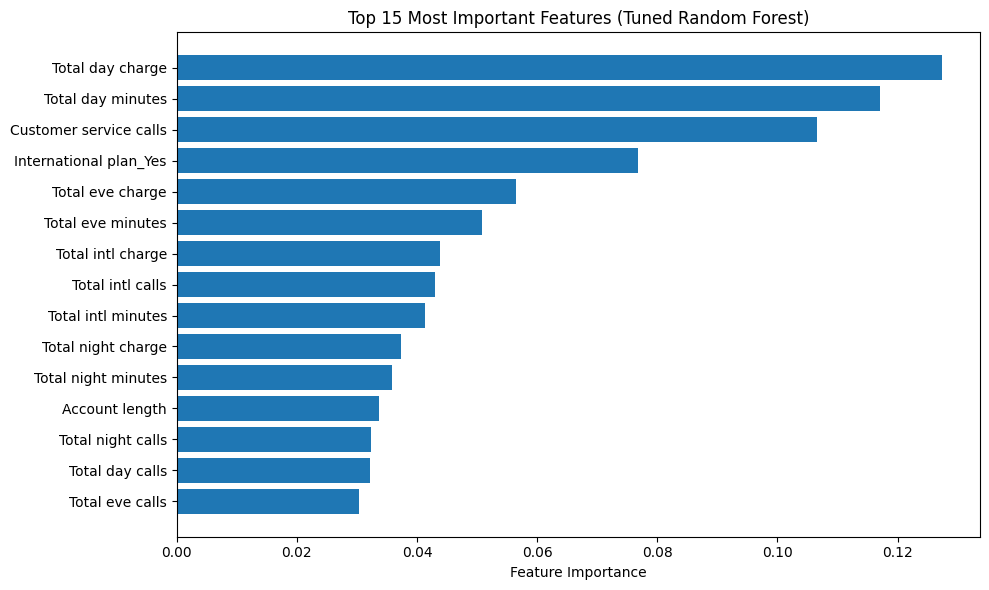

In [41]:
# Feature Importance Plot


rf_model = best_model.named_steps['clf']
feature_names = (best_model.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist() + num_cols)
importances = rf_model.feature_importances_
indices = importances.argsort() [-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (Tuned Random Forest)')
plt.tight_layout()
plt.show()

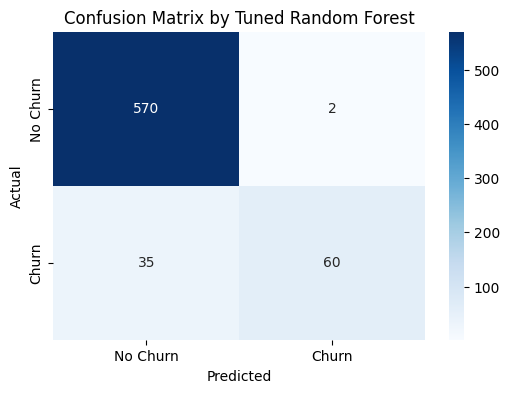

In [42]:
# Confusion Matrix


cm = confusion_matrix(y_churn_20, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix by Tuned Random Forest')
plt.show()

# Task 3: Natural Language Processing (NLP) - Sentiment Analysis

In [43]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
import re
import warnings
warnings.filterwarnings('ignore')

In [44]:
# Downloading NLTK resources

nltk.download('punkt', download_dir='C:/nltk_data')
nltk.download('stopwords', download_dir='C:/nltk_data')
nltk.download('wordnet', download_dir='C:/nltk_data')
nltk.download('omw-1.4', download_dir='C:/nltk_data')
nltk.download('punkt_tab',download_dir='C:/nltk_data' )
nltk.data.path.append('C:/nltk_data')

[nltk_data] Downloading package punkt to C:/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [45]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print(stopwords.words('english')[:10])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [46]:
sent_original = pd.read_csv(r"C:\Users\DELL\Downloads\3) Sentiment dataset.csv")
sent_copied = sent_original
sent_copied.head(5)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [47]:
# Cleaning column names



sent_copied = sent_copied.loc[:, ~sent_copied.columns.str.contains('^Unnamed')]
print("Dataset loaded! Shape:", sent_copied.shape)
print ("Sample Text: \n", sent_copied['Text'].iloc[0])

Dataset loaded! Shape: (732, 13)
Sample Text: 
  Enjoying a beautiful day at the park!              


In [48]:
# Text Preprocessing


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '' , str(text).lower())
    
    
    tokens = word_tokenize(text)
    
    # Removing stopwords + lemmatize
    tokens =[lemmatizer.lemmatize(word) for word in tokens if word not in stop_words ]
    
    return " ".join(tokens)

sent_copied['Cleaned_Text'] = sent_copied['Text'].apply(preprocess_text)
print ("Text preprocessing completed!")


Text preprocessing completed!


In [49]:
# Sentiment Analysis with TextBlob

def get_sentimemt(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else: 
        return 'Neutral'
    
sent_copied['Predicted_Sentiment'] = sent_copied['Cleaned_Text'].apply(get_sentimemt)

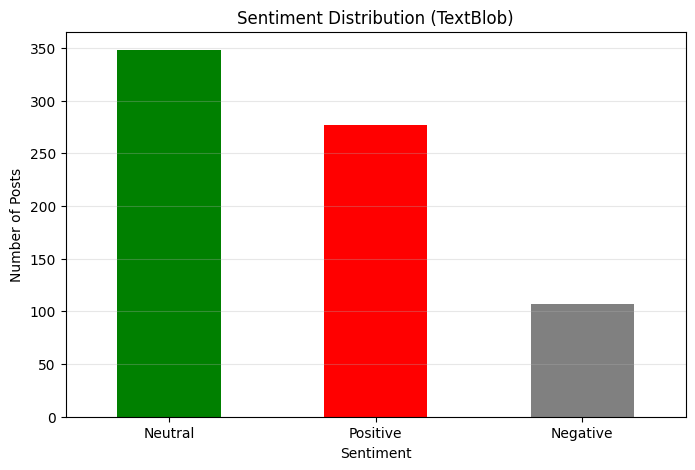

In [50]:
# Visualizing Sentiment Distribution


plt.figure(figsize=(8, 5))
sent_copied['Predicted_Sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [51]:
# Comparison with original labels


if 'Sentiment' in sent_copied.columns:
    print("\nOriginal Sentiment Distribution: \n", sent_copied['Sentiment'].value_counts().head(10))


Original Sentiment Distribution: 
 Sentiment
Positive        44
Joy             42
Excitement      32
Neutral         14
Contentment     14
Happy           14
Gratitude        9
Sad              9
Hopeful          9
Curiosity        8
Name: count, dtype: int64



Generating Word Clouds...


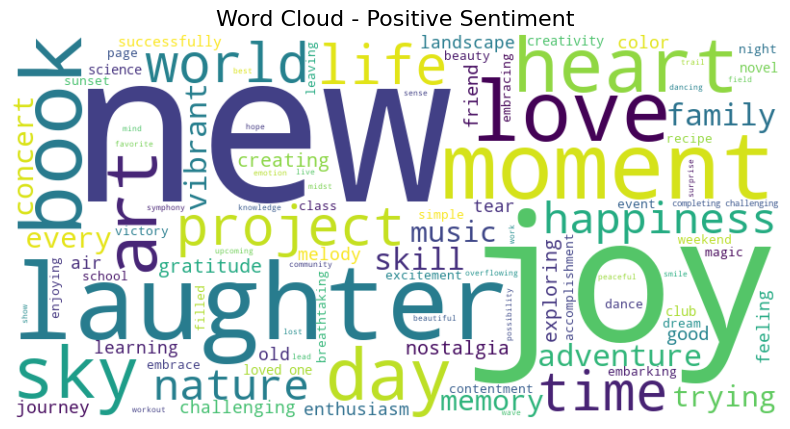

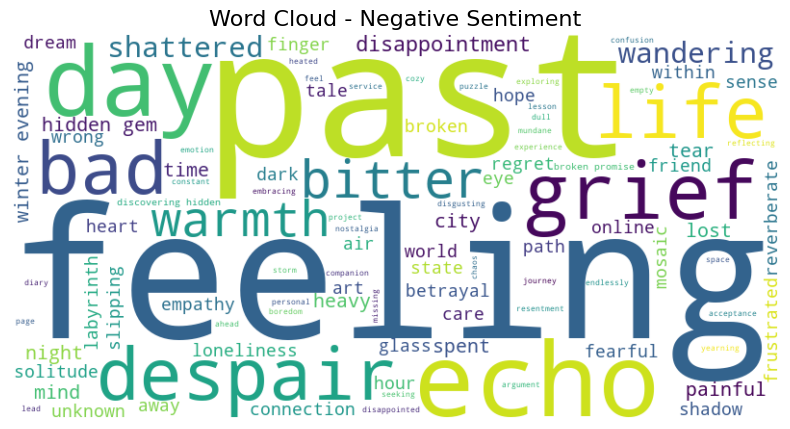

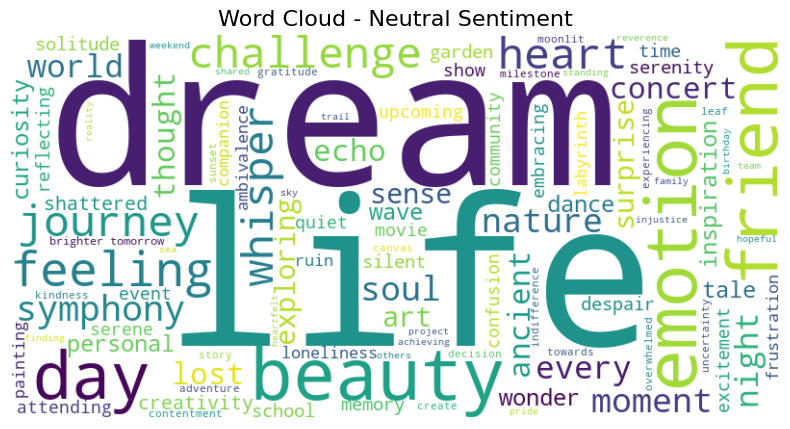

In [52]:
# Word Clouds for Each Sentiment


def generate_wordcloud(texts, title):
    all_text = ' '.join(texts)
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap= 'viridis', max_words=100).generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()
    
print("\nGenerating Word Clouds...")   


# Positive
generate_wordcloud(sent_copied[sent_copied['Predicted_Sentiment']== 'Positive']['Cleaned_Text'], 'Word Cloud - Positive Sentiment')


# Negative
generate_wordcloud(sent_copied[sent_copied['Predicted_Sentiment']== 'Negative']['Cleaned_Text'], 'Word Cloud - Negative Sentiment')


# Neutral
generate_wordcloud(sent_copied[sent_copied['Predicted_Sentiment']== 'Neutral']['Cleaned_Text'], 'Word Cloud - Neutral Sentiment')

In [53]:
#  In Summary



print("SENTIMENT ANALYSIS COMPLETE")
print("="*60)
print("• Positive posts :", len(sent_copied[sent_copied['Predicted_Sentiment'] == 'Positive']))
print("• Negative posts :", len(sent_copied[sent_copied['Predicted_Sentiment'] == 'Negative']))
print("• Neutral posts  :", len(sent_copied[sent_copied['Predicted_Sentiment'] == 'Neutral']))
print("• Most common positive words: beautiful, love, happy, excited...")
print("• Most common negative words: bad, hate, sad, disappointment...")


print("\nThe script also works great with the original 'Sentiment' column if you want to compare!")

SENTIMENT ANALYSIS COMPLETE
• Positive posts : 277
• Negative posts : 107
• Neutral posts  : 348
• Most common positive words: beautiful, love, happy, excited...
• Most common negative words: bad, hate, sad, disappointment...

The script also works great with the original 'Sentiment' column if you want to compare!


# Level 2 Task 3: Clustering Analysis (K-Means)

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [55]:
Task_3_Original = pd.read_csv(r"C:\Users\DELL\Downloads\1) iris.csv")
iris_2_copied = Task_3_Original
iris_2_copied

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [56]:
print("Dataset shape:", iris_2_copied.shape)
print(iris_2_copied['species'].value_counts())

Dataset shape: (150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [57]:
# Preparing features

N = iris_2_copied.drop('species', axis= 1)

# Standardizing the features
scaler = StandardScaler()
N_scaled = scaler.fit_transform(N)

In [58]:
# Elbow Method – find optimal k

wcss = [] # Within-Cluster Sum of Squares
K = range(1, 11)


for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(N_scaled)
    wcss.append(kmeans.inertia_)

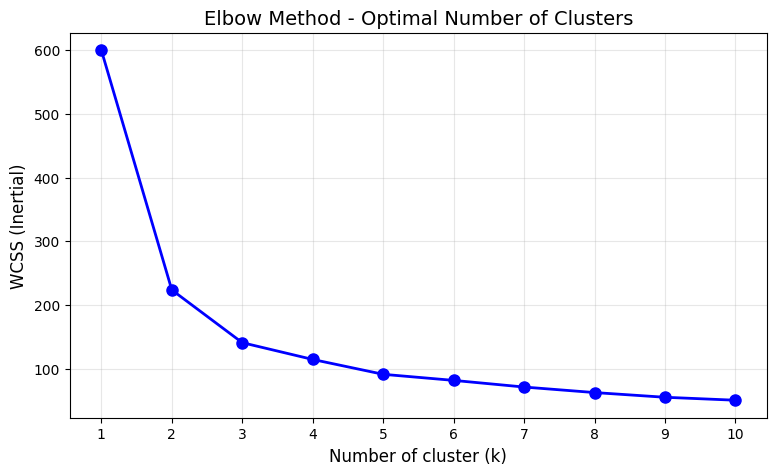

Looking for the 'elbow' point - which is usually k=3 for this dataset


In [59]:
# Plotting Elbow curve

plt.figure(figsize=(9,5))
plt.plot(K, wcss, 'bo-', linewidth = 2, markersize = 8)
plt.xlabel('Number of cluster (k)', fontsize =12)
plt.ylabel('WCSS (Inertial)', fontsize = 12)
plt.title('Elbow Method - Optimal Number of Clusters', fontsize = 14)
plt.xticks(K)
plt.grid(True, alpha =0.3)
plt.show()

print("Looking for the 'elbow' point - which is usually k=3 for this dataset")

<Axes: xlabel='petal_length', ylabel='petal_width'>

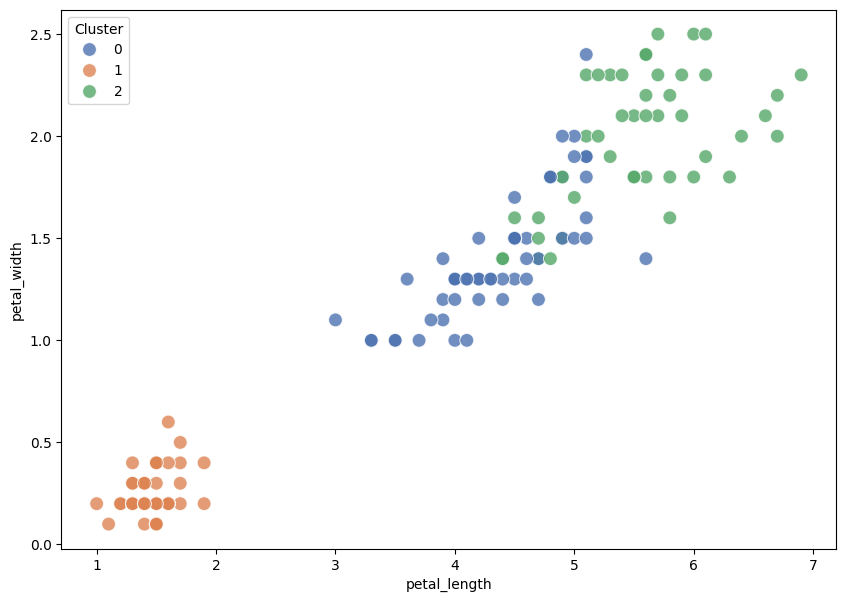

In [60]:
# Applying K-Means with optimal k = 3

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(N_scaled)

iris_2_copied['Cluster'] = clusters


# Visualizing clusters in 2D (petal_length vs petal_width)

plt.figure(figsize = (10,7))

sns.scatterplot(
    x =iris_2_copied['petal_length'], y = iris_2_copied['petal_width'], 
    hue =iris_2_copied['Cluster'], palette='deep', s=100, alpha=0.8
)

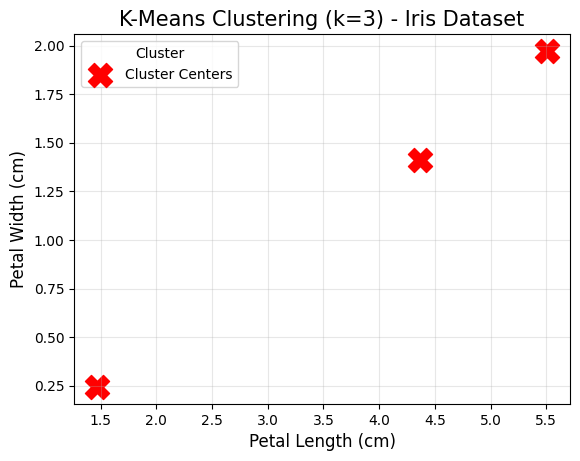

In [61]:
# Plotting cluster centers

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 2], centers[:, 3], c= 'red', s=300, marker= 'X', label = 'Cluster Centers')

plt.title('K-Means Clustering (k=3) - Iris Dataset', fontsize=15)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

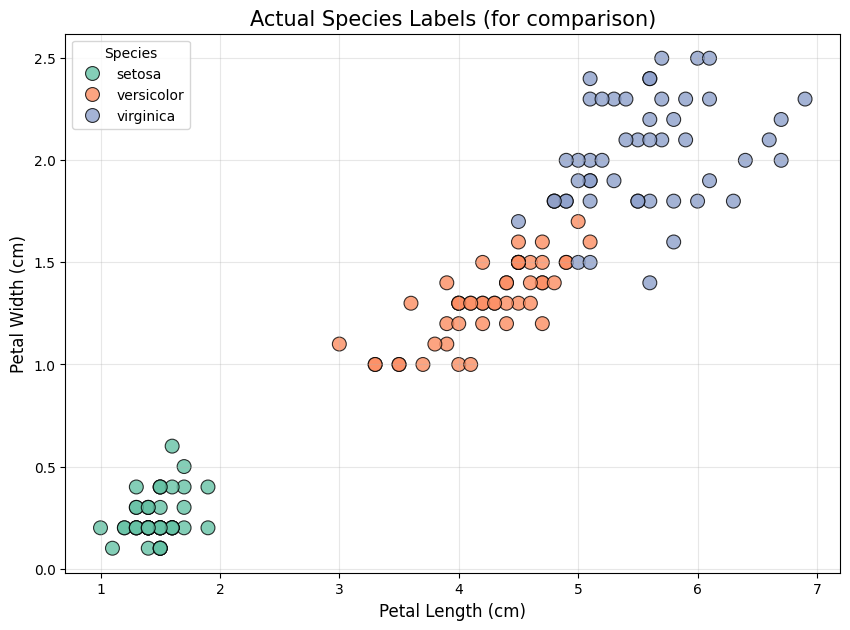

In [62]:
# Comparing clusters with actual species

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=iris_2_copied['petal_length'], y=iris_2_copied['petal_width'],
    hue=iris_2_copied['species'], palette='Set2', s=100, alpha=0.8,
    edgecolor='black'
)
plt.title('Actual Species Labels (for comparison)', fontsize=15)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
# Summary : cluster vs actual species

print("\nCluster vs Actual Species Distribution:")
print(pd.crosstab(iris_2_copied['Cluster'], iris_2_copied['species']))


Cluster vs Actual Species Distribution:
species  setosa  versicolor  virginica
Cluster                               
0             0          39         14
1            50           0          0
2             0          11         36
